<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [148]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [166]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [165]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [167]:
class_labels = train_data.classes
len(train_data), len(test_data)

(60000, 10000)

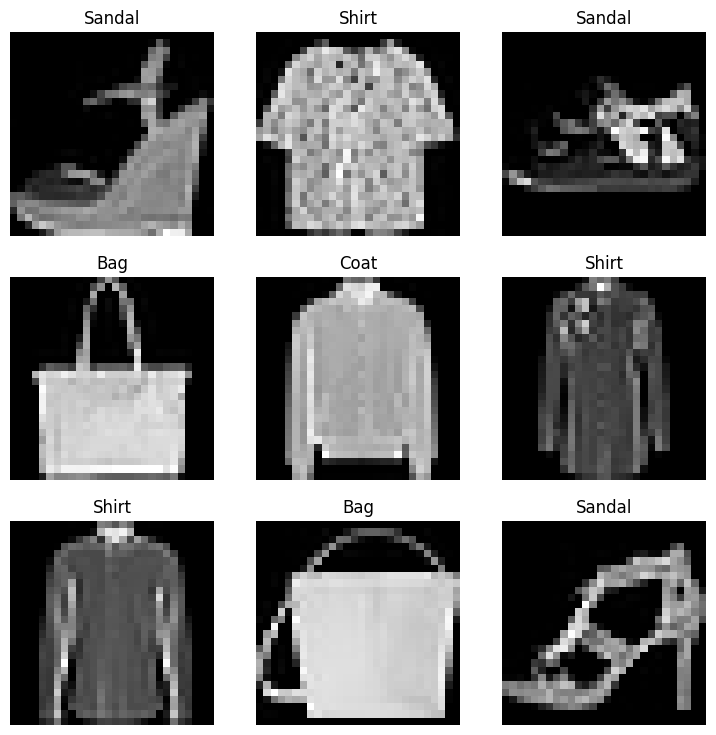

In [152]:
seed = 13
torch.manual_seed(seed)
class_map = train_data.classes
fig = plt.figure(figsize=(9,9))
rows, cols = 3, 3

for i in range(9):
    rand_idx = torch.randint(0, len(train_data), [1]).item()
    image, label = train_data[rand_idx]
    fig.add_subplot(rows, cols, i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_map[label])
    plt.axis(False)

In [153]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [154]:
torch.manual_seed(13)
train_data, val_data = random_split(
    train_data,
    [5/6, 1/6]
)
print(len(train_data), len(val_data))

50000 10000


In [155]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_data, batch_size=64, num_workers=2)

next(iter(train_dataloader))[0].shape

torch.Size([64, 1, 28, 28])

In [156]:
def train_model(model, epochs, criterion, optimizer, train_dataloder, val_dataloader):
    epochs = 10
    train_losses = []
    val_losses = []
    val_accuracies = []
    best_params_dict = None
    best_val_loss = float('infinity')

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for X, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            running_train_loss += loss.item()
            loss.backward()
            optimizer.step()
        train_loss = running_train_loss / len(train_dataloader)
        train_losses.append(train_loss)

        model.eval()
        correct = 0
        total = 0
        running_val_loss = 0.0
        with torch.inference_mode():
            for X, y in val_dataloader:
                pred_logits = model(X)
                loss = criterion(pred_logits, y)
                predictions = torch.argmax(pred_logits, dim=1)
                total += y.size(0)
                correct += (y == predictions).sum().item()
                running_val_loss += loss.item()
        val_loss = running_val_loss / len(val_dataloader)
        val_losses.append(val_loss)
        acc = correct / total
        val_accuracies.append(acc)
        print(f"Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss} | Val Loss: {val_loss} | Val Accuracy: {acc}")

        if (val_loss < best_val_loss):
            best_val_loss = val_loss
            best_params_dict = model.state_dict()
            print(f"Best Val Loss: {val_loss} | Saving state_dict...")
    return best_params_dict, train_losses, val_losses, val_accuracies

In [157]:
def plot_results(train_losses, val_losses, val_accuracies):
    fig, ax = plt.subplots(1, 2)
    ax[0].plot(train_losses, label="Train Losses")
    ax[0].plot(val_losses, label="Val Losses")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Epoch vs Loss")
    ax[0].legend()

    ax[1].plot(val_accuracies, label="Val Accuracies")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_title("Epoch vs Validation Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

In [158]:
def run_test(model, best_state_dict, test_dataloader, loss_fn):
    model.load_state_dict(best_state_dict)
    model.eval()
    predicted_labels = []
    true_labels = []
    total_test_loss = 0.0
    with torch.inference_mode():
        for X, y in test_dataloader:
            logits = model(X)
            total_test_loss += loss_fn(logits, y).item()
            preds = torch.argmax(logits, dim=1)
            predicted_labels.extend(preds.cpu().tolist())
            true_labels.extend(y.cpu().tolist())
    acc = accuracy_score(true_labels, predicted_labels)
    cm = confusion_matrix(true_labels, predicted_labels)
    print(f"Test Accuracy: {acc:.2f} | Test Loss: {total_test_loss/len(test_dataloader):.4f}")
    disp = ConfusionMatrixDisplay(cm, display_labels=train_data.classes)
    disp.plot()

    plt.show()


In [159]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*7*7, 1024),
    nn.ReLU(),

    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Linear(512, 10)
)

In [160]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-3, weight_decay=1e-5)

In [161]:
best_params_dict, train_losses, val_losses, val_accuracies = train_model(model, 10, criterion, optimizer, train_dataloader, val_dataloader)

Epoch 1/10: 100%|██████████| 782/782 [01:15<00:00, 10.31it/s]


Epoch: 1/10 | Train Loss: 0.41385032974012065 | Val Loss: 0.2690289328527299 | Val Accuracy: 0.904
Best Val Loss: 0.2690289328527299 | Saving state_dict...


Epoch 2/10: 100%|██████████| 782/782 [01:13<00:00, 10.68it/s]


Epoch: 2/10 | Train Loss: 0.27267109278751456 | Val Loss: 0.2713711780917113 | Val Accuracy: 0.8995


Epoch 3/10: 100%|██████████| 782/782 [01:12<00:00, 10.77it/s]


...

Epoch: 8/10 | Train Loss: 0.11099731864269509 | Val Loss: 0.2383581387341782 | Val Accuracy: 0.9248


Epoch 9/10: 100%|██████████| 782/782 [01:12<00:00, 10.82it/s]


Epoch: 9/10 | Train Loss: 0.09288806085774909 | Val Loss: 0.2539419554838329 | Val Accuracy: 0.9222


Epoch 10/10: 100%|██████████| 782/782 [01:12<00:00, 10.74it/s]


Epoch: 10/10 | Train Loss: 0.08132227070009113 | Val Loss: 0.2977936199990807 | Val Accuracy: 0.9253


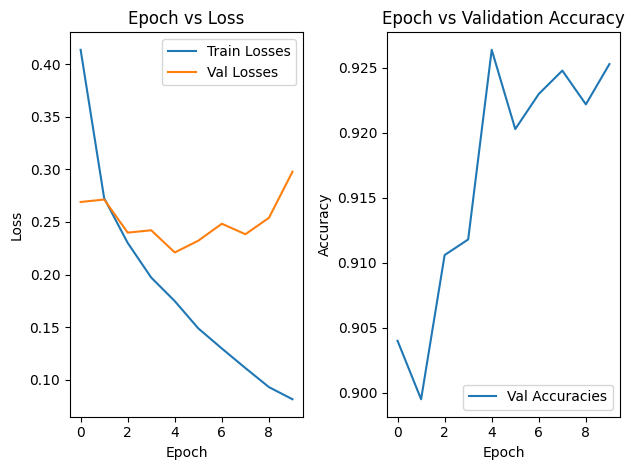

In [162]:
plot_results(train_losses, val_losses, val_accuracies)

Test Accuracy: 0.92 | Test Loss: 0.3214


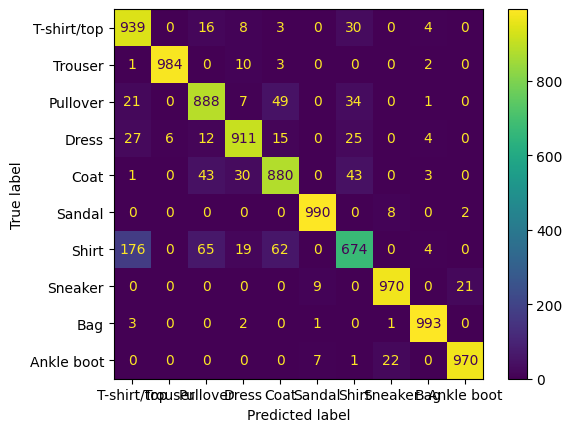

In [168]:
run_test(model, best_params_dict, test_dataloader, criterion)

In [169]:
model_2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64, 10)
)

In [170]:
optimizer_2 = torch.optim.SGD(params=model_2.parameters(), lr=0.05, momentum=0.9)

best_model_state, train_losses, val_losses, val_accs = train_model(model_2, 10, criterion, optimizer_2, train_dataloader, val_dataloader)

Epoch 1/10: 100%|██████████| 782/782 [00:45<00:00, 17.08it/s]


Epoch: 1/10 | Train Loss: 0.7755962954762646 | Val Loss: 0.8529708393060478 | Val Accuracy: 0.6869
Best Val Loss: 0.8529708393060478 | Saving state_dict...


Epoch 2/10: 100%|██████████| 782/782 [00:46<00:00, 16.76it/s]


Epoch: 2/10 | Train Loss: 0.5004027700408951 | Val Loss: 0.6421079977302794 | Val Accuracy: 0.7791
Best Val Loss: 0.6421079977302794 | Saving state_dict...


Epoch 3/10: 100%|██████████| 782/782 [00:45<00:00, 17.03it/s]


...

Epoch: 8/10 | Train Loss: 0.3297138712214082 | Val Loss: 0.49746227976243207 | Val Accuracy: 0.8353


Epoch 9/10: 100%|██████████| 782/782 [00:45<00:00, 17.36it/s]


Epoch: 9/10 | Train Loss: 0.3223651980461977 | Val Loss: 0.4200844082293237 | Val Accuracy: 0.8513


Epoch 10/10: 100%|██████████| 782/782 [00:44<00:00, 17.53it/s]


Epoch: 10/10 | Train Loss: 0.3094561138688146 | Val Loss: 0.36491246777734937 | Val Accuracy: 0.8632


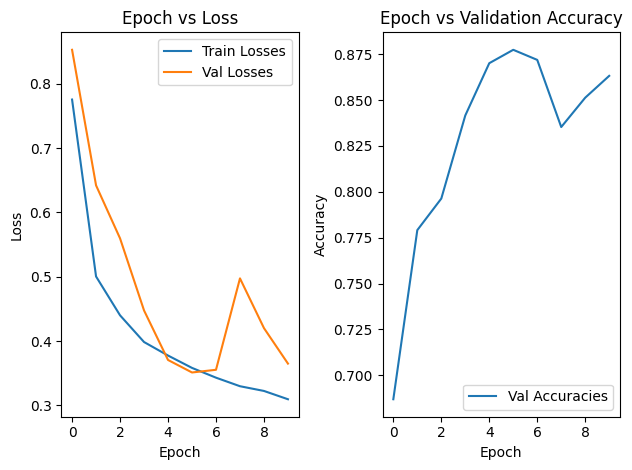

In [171]:
plot_results(train_losses, val_losses, val_accs)

Test Accuracy: 0.86 | Test Loss: 0.4078


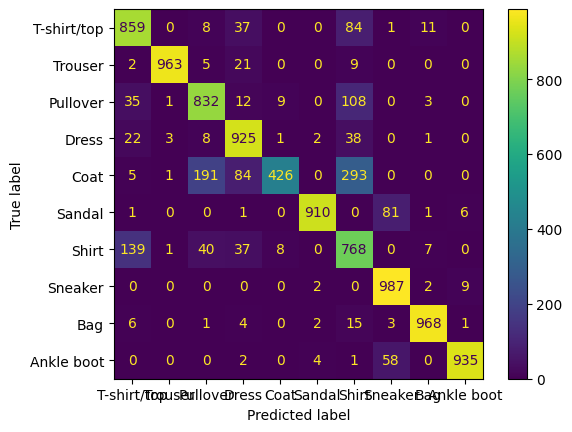

In [172]:
run_test(model_2, best_model_state, test_dataloader, criterion)

In [173]:
optimizer_2_2 = torch.optim.SGD(params=model_2.parameters(), lr=0.1, momentum=0.9)
model_2.apply(
    lambda m: m.reset_parameters()
    if hasattr(m, "reset_parameters")
    else None
)
best_model_state, train_losses, val_losses, val_accs = train_model(model_2, 10, criterion, optimizer_2_2, train_dataloader, val_dataloader)

Epoch 1/10: 100%|██████████| 782/782 [00:44<00:00, 17.49it/s]


Epoch: 1/10 | Train Loss: 0.740033713143195 | Val Loss: 0.6363627384802338 | Val Accuracy: 0.7857
Best Val Loss: 0.6363627384802338 | Saving state_dict...


Epoch 2/10: 100%|██████████| 782/782 [00:45<00:00, 17.34it/s]


Epoch: 2/10 | Train Loss: 0.48658344054313574 | Val Loss: 0.5516436015534553 | Val Accuracy: 0.8072
Best Val Loss: 0.5516436015534553 | Saving state_dict...


Epoch 3/10: 100%|██████████| 782/782 [00:44<00:00, 17.44it/s]


...

Epoch: 8/10 | Train Loss: 0.32742501065477997 | Val Loss: 0.32047137414004395 | Val Accuracy: 0.885
Best Val Loss: 0.32047137414004395 | Saving state_dict...


Epoch 9/10: 100%|██████████| 782/782 [00:45<00:00, 17.32it/s]


Epoch: 9/10 | Train Loss: 0.31265341113214296 | Val Loss: 0.31079280656424296 | Val Accuracy: 0.8879
Best Val Loss: 0.31079280656424296 | Saving state_dict...


Epoch 10/10: 100%|██████████| 782/782 [00:44<00:00, 17.66it/s]


Epoch: 10/10 | Train Loss: 0.3106816773638701 | Val Loss: 0.338828758781503 | Val Accuracy: 0.8768


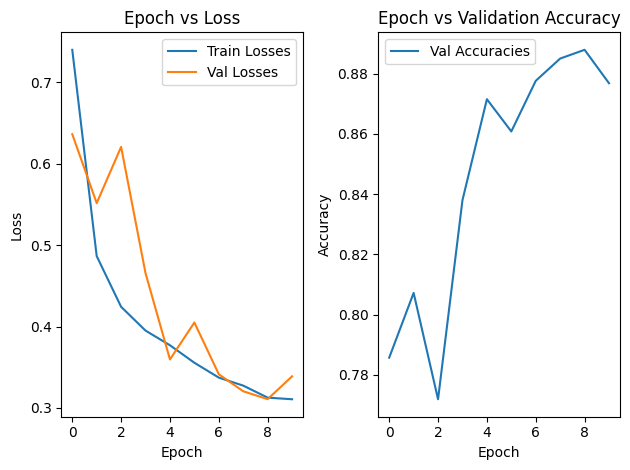

In [174]:
plot_results(train_losses, val_losses, val_accs)

Test Accuracy: 0.87 | Test Loss: 0.3823


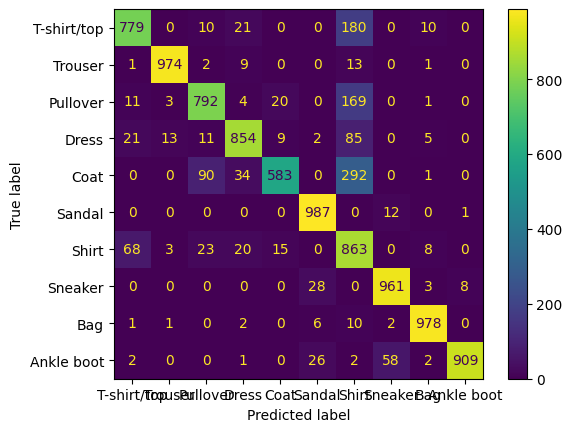

In [175]:
run_test(model_2, best_model_state, test_dataloader, criterion)

In [189]:
optimizer_2_3 = torch.optim.AdamW(params=model_2.parameters(), lr=1e-2, weight_decay=1e-5)
model_2.apply(
    lambda m: m.reset_parameters()
    if hasattr(m, "reset_parameters")
    else None
)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): AdaptiveAvgPool2d(output_size=1)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=64, out_features=10, bias=True)
)

In [190]:
best_model_state, train_losses, val_losses, val_accs = train_model(model_2, 10, criterion, optimizer_2_3, train_dataloader, val_dataloader)

Epoch 1/10: 100%|██████████| 782/782 [00:45<00:00, 17.10it/s]


Epoch: 1/10 | Train Loss: 0.7058574831699167 | Val Loss: 1.032253030379107 | Val Accuracy: 0.631
Best Val Loss: 1.032253030379107 | Saving state_dict...


Epoch 2/10: 100%|██████████| 782/782 [00:45<00:00, 17.15it/s]


Epoch: 2/10 | Train Loss: 0.46682611589922623 | Val Loss: 0.46715844066659357 | Val Accuracy: 0.8351
Best Val Loss: 0.46715844066659357 | Saving state_dict...


Epoch 3/10: 100%|██████████| 782/782 [00:45<00:00, 17.28it/s]


...

Epoch: 8/10 | Train Loss: 0.3119436967022279 | Val Loss: 0.3669772708112267 | Val Accuracy: 0.8661
Best Val Loss: 0.3669772708112267 | Saving state_dict...


Epoch 9/10: 100%|██████████| 782/782 [00:45<00:00, 17.17it/s]


Epoch: 9/10 | Train Loss: 0.3031042674580193 | Val Loss: 0.3410020910061089 | Val Accuracy: 0.8819
Best Val Loss: 0.3410020910061089 | Saving state_dict...


Epoch 10/10: 100%|██████████| 782/782 [00:45<00:00, 17.16it/s]


Epoch: 10/10 | Train Loss: 0.2914227891589522 | Val Loss: 0.2945993008317461 | Val Accuracy: 0.8972
Best Val Loss: 0.2945993008317461 | Saving state_dict...


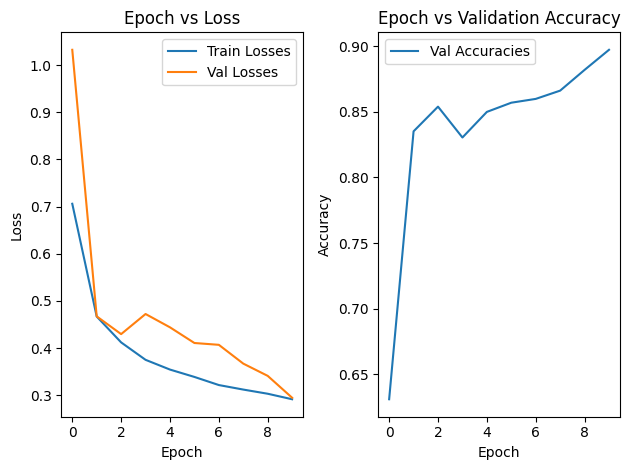

In [191]:
plot_results(train_losses, val_losses, val_accs)

Test Accuracy: 0.88 | Test Loss: 0.3315


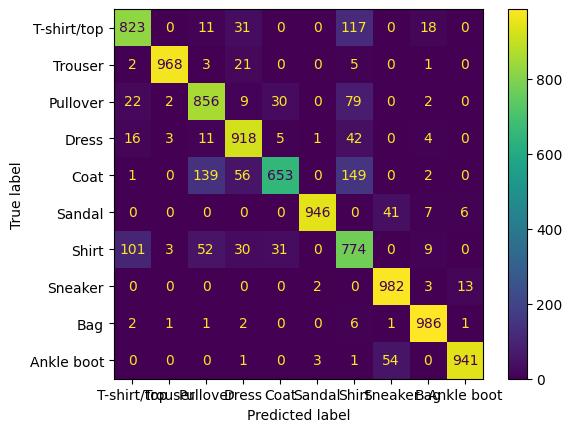

In [192]:
run_test(model_2, best_model_state, test_dataloader, criterion)

In [181]:
model_3 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64, 10)
)

optimizer_3 = torch.optim.AdamW(params=model_3.parameters(), lr=1e-3, weight_decay=1e-3)

In [182]:
best_model_state, train_losses, val_losses, val_accs = train_model(model_3, 10, criterion, optimizer_3, train_dataloader, val_dataloader)

Epoch 1/10: 100%|██████████| 782/782 [00:45<00:00, 17.14it/s]


Epoch: 1/10 | Train Loss: 1.03053392473694 | Val Loss: 0.8151679498374842 | Val Accuracy: 0.7336
Best Val Loss: 0.8151679498374842 | Saving state_dict...


Epoch 2/10: 100%|██████████| 782/782 [00:55<00:00, 14.15it/s]


Epoch: 2/10 | Train Loss: 0.6467584191685747 | Val Loss: 0.594576356137634 | Val Accuracy: 0.8028
Best Val Loss: 0.594576356137634 | Saving state_dict...


Epoch 3/10: 100%|██████████| 782/782 [00:45<00:00, 17.08it/s]


...

Epoch: 8/10 | Train Loss: 0.4024317530376832 | Val Loss: 0.39694501136898236 | Val Accuracy: 0.8613
Best Val Loss: 0.39694501136898236 | Saving state_dict...


Epoch 9/10: 100%|██████████| 782/782 [00:46<00:00, 16.86it/s]


Epoch: 9/10 | Train Loss: 0.3875799048549074 | Val Loss: 0.41088738828707655 | Val Accuracy: 0.8527


Epoch 10/10: 100%|██████████| 782/782 [00:45<00:00, 17.04it/s]


Epoch: 10/10 | Train Loss: 0.3756855174975322 | Val Loss: 0.38441147289838 | Val Accuracy: 0.8707
Best Val Loss: 0.38441147289838 | Saving state_dict...


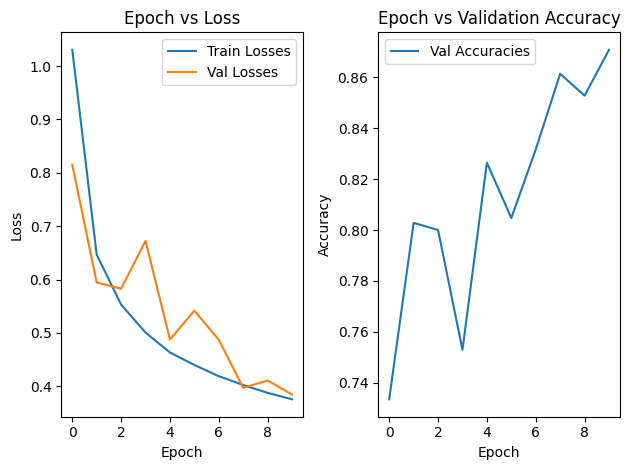

In [183]:
plot_results(train_losses, val_losses, val_accs)

Test Accuracy: 0.86 | Test Loss: 0.4081


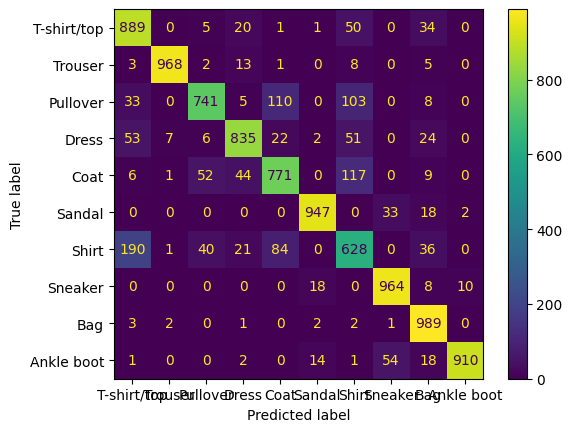

In [184]:
run_test(model_3, best_model_state, test_dataloader, criterion)

In [185]:
model_4 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.AdaptiveAvgPool2d(2),
    nn.Flatten(),
    nn.Linear(256, 128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

optimizer_4 = torch.optim.AdamW(params=model_4.parameters(), lr=1e-3, weight_decay=1e-5)

In [186]:
best_model_state, train_losses, val_losses, val_accs = train_model(model_4, 10, criterion, optimizer_4, train_dataloader, val_dataloader)

Epoch 1/10: 100%|██████████| 782/782 [00:48<00:00, 16.28it/s]


Epoch: 1/10 | Train Loss: 0.6325427129712251 | Val Loss: 0.4706570722494915 | Val Accuracy: 0.8241
Best Val Loss: 0.4706570722494915 | Saving state_dict...


Epoch 2/10: 100%|██████████| 782/782 [00:47<00:00, 16.39it/s]


Epoch: 2/10 | Train Loss: 0.41099200900786975 | Val Loss: 0.43083947678660134 | Val Accuracy: 0.8478
Best Val Loss: 0.43083947678660134 | Saving state_dict...


Epoch 3/10: 100%|██████████| 782/782 [00:47<00:00, 16.53it/s]


...

Epoch: 8/10 | Train Loss: 0.26476838612152487 | Val Loss: 0.3117475102471698 | Val Accuracy: 0.8863


Epoch 9/10: 100%|██████████| 782/782 [00:47<00:00, 16.48it/s]


Epoch: 9/10 | Train Loss: 0.25331472284386836 | Val Loss: 0.2626730478872919 | Val Accuracy: 0.9027
Best Val Loss: 0.2626730478872919 | Saving state_dict...


Epoch 10/10: 100%|██████████| 782/782 [00:47<00:00, 16.46it/s]


Epoch: 10/10 | Train Loss: 0.24483072986859647 | Val Loss: 0.26571726222421715 | Val Accuracy: 0.9052


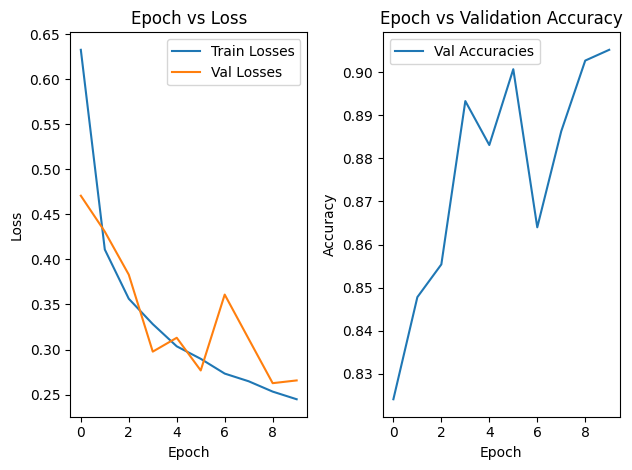

In [187]:
plot_results(train_losses, val_losses, val_accs)

Test Accuracy: 0.90 | Test Loss: 0.3016


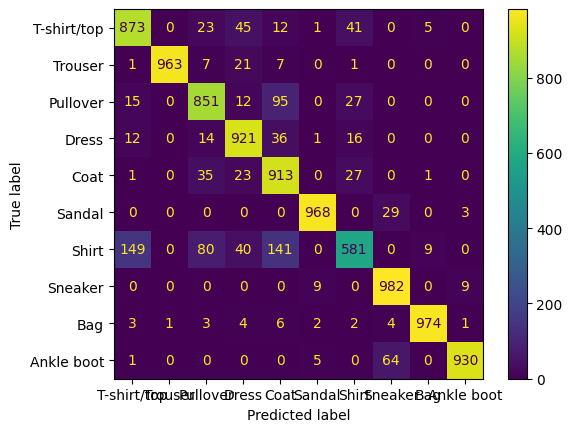

In [188]:
run_test(model_4, best_model_state, test_dataloader, criterion)

> To improve the models
* Almost all models could do better with more epochs of training
* Should pick the best model and the best optimizer